
# Introduction

---
Up to this point, we’ve covered the foundational concepts of machine learning. You may have already experimented with various hyperparameters to optimize model performance. In this notebook, you’ll be introduced to several advanced techniques designed to further enhance your models.


This notebook consists the following parts:

- [A: Data retrieval ](#01)
- [B: Feature engineering](#02)
- [C: Model evaluation](#03)
- [D: Ensemble learning](#04)
- [E: Pipelines](#05)
- [F: Bring it all together](#06)
- [G: Bonus: ML OPS](#07)


---

### Learning Objectives
By the end of this two weeks you will be able to:
- Understand the fundamental concepts of ensemble learning.
- Use evaluation techniques to assess models performance.
- Enhance model performance by feature engineering. 
- Build pipelines for model development and preprocessing

---

### Instructions
- Ensure you fully understand the requirements and objectives of the assignment.
- Review the notebooks refered in the tasks
- If you need additional context or clarification, please check the provided videos or background literature.
- Work through each part of the assignment methodically, ensuring all tasks are completed.
- Update your repository with your new created work

### Additional Notes:
- Do not add datafiles to your repository. Repositories with datafiles will not be accepted
- Class solutions should be delivered in python files. Not in notebooks
- When AI tools are used, you must provide proper references and explanations for how they were utilized. Failure to do so will be considered as academic fraud
- The bonus assignment are not mandatory
- Use PEP8 

Good luck!

F.Feenstra

---


<a name='01'></a>
## Part A. Data retrieval

The dataset you can use for this notebook is the lung dataset from Maastricht University. It comprises 89 non-small cell lung cancer (NSCLC) patients records who underwent surgical treatment. The study where the data is from explored the relationship between radiomic imaging features and gene expression profiles. The samples were collected through biopsies at MAASTRO Clinic in The Netherlands, and the dataset is publicly available.

The authors of the related paper discovered that a prognostic radiomic signature, which captures intra-tumor heterogeneity, is closely associated with underlying gene expression patterns. Developing a machine learning model to predict histology from the Clinical and Genetic Lung data can improve diagnostic accuracy and treatment personalization. In this notebook we will develop such a prediction model. 

**Availabel Datasets**:
- Lung metadata dataset [1]
- Gene expression dataset [2]

**Important**
<span style="background-color: lightgreen;color: black">It is also allowed to use your own dataset from your own project if this data is highly dimensional and contains genetic information.</span>

[1] [NSCLC-Radiomics-Genomics](https://wiki.cancerimagingarchive.net/display/Public/NSCLC-Radiomics-Genomics#16056856db10d39adf704eefa53e41edcf5ef41c)

[2] [Gene Expression Data - GSE58661](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE58nnn/GSE58661/matrix/)

[3] Aerts HJWL, Rios Velazquez E, Leijenaar RTH, Parmar C, Grossmann P, Carvalho S, Bussink J, Monshouwer R, Haibe-Kains B, Rietveld D, Hoebers F, Rietbergen MM, Leemans CR, Dekker A, Quackenbush J, Gillies RJ, & Lambin P. (2015). Data From NSCLC-Radiomics-Genomics. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2015.L4FRET6Z


### <span style="background-color: lightyellow;">Data retrieval task</span>
- Retrieve the data. (No cleaning needed yet)

In [30]:
import pandas as pd
import gzip

# Read file
with gzip.open('GSE58661_series_matrix.txt.gz', 'rt') as f:
    gene_expression = pd.read_csv(f, delimiter="\t", comment='!')
    
gene_expression.to_csv('gene_expression_data.csv', index=False)
print("DataFrame created and saved successfully!")
gene_expression


DataFrame created and saved successfully!


,ID_REF,GSM1416528,GSM1416529,GSM1416530,GSM1416531,GSM1416532,GSM1416533,GSM1416534,GSM1416535,GSM1416536,...,GSM1416607,GSM1416608,GSM1416609,GSM1416610,GSM1416611,GSM1416612,GSM1416613,GSM1416614,GSM1416615,GSM1416616
0,AFFX-BioB-3_at,7.376915,8.024915,7.522543,7.152864,7.211031,7.704962,7.779374,7.136893,7.160221,...,7.611992,7.345206,7.316975,7.418340,7.756286,7.215856,7.465109,7.245458,7.039592,7.393667
1,AFFX-BioB-5_at,6.984530,7.427048,7.077207,6.849513,6.753131,7.195947,7.429800,6.745630,6.751358,...,7.175015,7.014479,6.913879,6.898449,7.347570,6.740992,7.080787,6.725812,6.575376,7.041106
2,AFFX-BioB-M_at,7.330576,8.010530,7.334551,7.143286,7.077163,7.753484,7.712429,7.036303,7.089186,...,7.612393,7.285821,7.324635,7.408880,7.745624,7.152722,7.422373,7.263596,6.975162,7.366620
3,AFFX-BioC-3_at,10.922741,11.390638,10.936703,10.791909,10.701328,11.221732,11.084229,10.588372,10.628909,...,11.097486,10.908682,10.781228,10.935723,11.200635,10.707980,10.736531,10.770440,10.367009,10.753221
4,AFFX-BioC-5_at,11.032030,11.533338,11.018510,10.875259,10.823792,11.276973,11.178643,10.700420,10.779332,...,11.265739,10.990373,10.900765,11.101546,11.343329,10.842697,10.900509,10.838008,10.494806,10.863600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60602,merck2-Z48633_s_at,10.286077,11.173715,10.586540,10.257621,10.634072,10.741879,9.823555,9.715532,9.966245,...,11.189195,11.522115,10.793982,11.744113,11.147193,11.010846,9.975013,10.044351,8.798358,10.444210
60603,merck2-Z70222_a_at,6.892053,5.513603,6.112918,6.276813,7.041829,7.560786,7.446324,7.821045,7.465401,...,7.028523,6.229570,7.543618,7.518894,6.541189,6.493021,7.952822,6.978308,7.460604,7.519374
60604,merck2-Z70608_x_at,1.777216,1.940099,1.753519,1.889742,1.686633,1.988420,1.723665,2.029634,1.986343,...,3.246869,1.910438,1.910438,2.054199,1.730252,1.924313,1.783032,1.371800,1.811532,2.444065
60605,merck2-Z72499_a_at,9.031084,9.527973,9.515653,9.383670,9.464486,9.558521,9.651009,9.479608,9.417764,...,9.349558,9.377011,9.379870,9.398441,9.269749,9.223950,9.481911,9.632680,9.313734,9.527973


In [31]:
# gene_expression.dtypes


In [32]:
# Load the lung metadata from the Excel file
lung_metadata = pd.read_excel('Lung3.metadata.xls')

print(lung_metadata.head())

  sample.name   title      CEL.file   source.location      organism  \
0    LUNG3-01  lung_1  LUNG3-01.CEL  Left  Lower Lobe  Homo sapiens   
1    LUNG3-02  lung_2  LUNG3-02.CEL  Left  Lower Lobe  Homo sapiens   
2    LUNG3-03  lung_3  LUNG3-03.CEL  Left  Lower Lobe  Homo sapiens   
3    LUNG3-04  lung_4  LUNG3-04.CEL  Left  Lower Lobe  Homo sapiens   
4    LUNG3-05  lung_5  LUNG3-05.CEL  Left  Lower Lobe  Homo sapiens   

  characteristics.tag.gender  \
0                          M   
1                          M   
2                          M   
3                          M   
4                          F   

                       characteristics.tag.histology  \
0                       Squamous Cell Carcinoma, NOS   
1                     Adenocarcinoma, Papillary, NOS   
2                                     Non-Small Cell   
3  Papillary Type AND      Adenocarcinoma, Bronch...   
4                       Squamous Cell Carcinoma, NOS   

   characteristics.tag.tumor.size.maximumdi

In [33]:
# lung_metadata.dtypes

---
<a name='02'></a>
## Part B. Feature engineering

Mind you that choosing an algorithm and hyperparameter tuning might not be enough. If your data is of low quality, the algorithm will have poor performance as well. This is where feature engineering comes into play. Feature engineering involves transforming raw data into meaningful features that better represent the underlying problem to the predictive models, ultimately enhancing the model's performance. By selecting, creating, and refining features, you ensure that your data highlights the most relevant patterns and relationships, allowing the algorithm to learn more effectively. Proper feature engineering can often make the difference between a moderate model and a highly accurate one, even more so than the choice of algorithm itself. 
Possible modifications:
- creation of new features derived from original features
- selection of features
- encoding features
- log transformation 
- scaling
- dimension reduction (*e.g.* PCA)

### <span style="background-color: lightyellow;">Feature engineering Task</span>
- Review the [Study Case Feature Engineering notebook](../Study_Cases/study_case_feature_engineering.ipynb).
- Review the [Study Case RNA-seq Preparation notebook](../Study_Cases/study_case_scanpy_object.ipynb).
- Assess which data preparation and feature engineering steps could be beneficial for your dataset.
- Implement a `DataProcessor` class tailored to your dataset and test it in the cell below.
- Update your repository with a new directory named `optimization`, including the following:
    - The `DataProcessor` class as a Python file, complete with thorough documentation.
    - An evaluation document that details and justifies your choices using a well-reasoned, argumentative approach.



In [34]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

class DataProcessor:
    """
    A class for data processing and feature engineering tailored to the lung dataset.
    
    This class handles data preprocessing steps including feature selection, encoding, log transformation,
    scaling, and dimensionality reduction (PCA) as specified in the assignment criteria.
    """

    def __init__(self, gene_expression, lung_metadata):
        """
        Initializes the DataProcessor with gene expression and metadata DataFrames.
        
        Parameters:
            gene_expression (pd.DataFrame): The gene expression data.
            lung_metadata (pd.DataFrame): The metadata associated with the gene expression data.
        """
        self.gene_expression = gene_expression
        self.lung_metadata = lung_metadata.copy()
    
    def run_pca(self, variance_threshold=0.95):
        """
        Runs PCA on the gene expression data and returns the PCA DataFrame and model.

        Parameters:
            variance_threshold (float): The amount of variance to retain during PCA.

        Returns:
            pd.DataFrame: DataFrame containing PCA-transformed features.
        """
        transposed_data = self.gene_expression.iloc[1:, 1:].T.apply(pd.to_numeric, errors='coerce').dropna(axis=1)
        pca = PCA(n_components=variance_threshold)
        pca_result = pca.fit_transform(transposed_data)
        pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])])
        return pca_df, pca
    
    def drop_single_unique_value_columns(self):
        """
        Drops columns from lung_metadata with a single unique value.
        """
        cols_to_drop = [col for col in self.lung_metadata.columns if self.lung_metadata[col].nunique() <= 1]
        self.lung_metadata.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    
    def encode_features(self):
        """
        Encodes categorical features in lung_metadata.
        """
        gender_mapping = {'M': 1, 'F': 0}
        stage_mapping = {'pT1': 1, 'pT2': 2, 'pT3': 3, 'pTX': 0, 'pN0': 0, 'pN1': 1, 'pNX': 0, 'pM0': 0, 'pM1': 1, 'pMX': 0}
        
        self.lung_metadata['source.location'] = self.lung_metadata['source.location'].astype('category').cat.codes
        self.lung_metadata['characteristics.tag.gender'] = self.lung_metadata['characteristics.tag.gender'].map(gender_mapping)
        
        unique_histology_values = self.lung_metadata['characteristics.tag.histology'].unique()
        histology_mapping = {value: idx for idx, value in enumerate(unique_histology_values, start=1)}
        histology_mapping['Not Available'] = 0
        self.lung_metadata['characteristics.tag.histology'] = self.lung_metadata['characteristics.tag.histology'].map(histology_mapping).fillna(0)

        self.lung_metadata['characteristics.tag.stage.primary.tumor'] = self.lung_metadata['characteristics.tag.stage.primary.tumor'].map(stage_mapping).fillna(0)
        self.lung_metadata['characteristics.tag.stage.nodes'] = self.lung_metadata['characteristics.tag.stage.nodes'].map(stage_mapping).fillna(0)
        self.lung_metadata['characteristics.tag.stage.mets'] = self.lung_metadata['characteristics.tag.stage.mets'].map(stage_mapping).fillna(0)
        
        self.lung_metadata['characteristics.tag.grade'] = self.lung_metadata['characteristics.tag.grade'].replace("Not Available", 0)
    
    def create_binary_features(self):
        """
        Creates binary features in lung_metadata.
        """
        if 'characteristics.tag.tumor.size.maximumdiameter' in self.lung_metadata.columns:
            self.lung_metadata['characteristics.tag.tumor.size.maximumdiameter'] = np.where(
                self.lung_metadata['characteristics.tag.tumor.size.maximumdiameter'] > 5, 1, 0
            )
    
    def merge_dataframes(self, pca_df):
        """
        Merges the PCA-transformed gene expression data with lung metadata.
        
        Parameters:
            pca_df (pd.DataFrame): DataFrame of PCA-transformed features.

        Returns:
            pd.DataFrame: Merged DataFrame with both PCA and lung metadata features.
        """
        self.lung_metadata.drop(columns=['title', 'CEL.file'], inplace=True, errors='ignore')
        combined_df = pd.merge(self.lung_metadata, pca_df, left_index=True, right_index=True, how='inner')
        return combined_df.dropna()
    
    def scale_and_transform(self, combined_df):
        """
        Applies log transformation and scaling to specified columns in the combined DataFrame.

        Parameters:
            combined_df (pd.DataFrame): The combined DataFrame to transform.

        Returns:
            pd.DataFrame: The transformed DataFrame.
        """
        if (combined_df['characteristics.tag.tumor.size.maximumdiameter'] > 0).all():
            combined_df['log_tumor_size'] = np.log(combined_df['characteristics.tag.tumor.size.maximumdiameter'])

        scaler = StandardScaler()
        
        # Dynamically select available PCA components for scaling
        pca_columns = [col for col in combined_df.columns if col.startswith('PC')]
        columns_to_scale = ['characteristics.tag.tumor.size.maximumdiameter'] + pca_columns
        combined_df[columns_to_scale] = scaler.fit_transform(combined_df[columns_to_scale])
        
        return combined_df



In [35]:
# Test of DataProcessor class
processor = DataProcessor(gene_expression, lung_metadata)
pca_df, _ = processor.run_pca()
processor.drop_single_unique_value_columns()
processor.encode_features()
processor.create_binary_features()
combined_df = processor.merge_dataframes(pca_df)
final_df = processor.scale_and_transform(combined_df)

# Display the final processed DataFrame
print(final_df.head())

  sample.name  source.location  characteristics.tag.gender  \
0    LUNG3-01                0                           1   
1    LUNG3-02                0                           1   
2    LUNG3-03                0                           1   
3    LUNG3-04                0                           1   
4    LUNG3-05                0                           0   

   characteristics.tag.histology  \
0                              1   
1                              2   
2                              3   
3                              4   
4                              1   

   characteristics.tag.tumor.size.maximumdiameter  \
0                                       -0.659912   
1                                       -0.659912   
2                                        1.515354   
3                                       -0.659912   
4                                        1.515354   

   characteristics.tag.stage.primary.tumor  characteristics.tag.stage.nodes  \
0           

In [36]:
# Define features (X) and target variable (y)
X = final_df.drop(columns=['characteristics.tag.histology'], errors='ignore')
y = final_df['characteristics.tag.histology']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (71, 81)
Testing Features Shape: (18, 81)
Training Labels Shape: (71,)
Testing Labels Shape: (18,)


Evaluation Document for Feature Engineering (Part B)
Objective:
The goal of feature engineering is to transform raw data into meaningful features that better represent the underlying patterns, making it easier for the machine learning model to learn effectively. This includes creating, selecting, encoding, and scaling features, as well as applying dimensionality reduction to highlight the most relevant patterns in the data.

1. Creation of New Features
Binary Feature for Tumor Size: A binary feature was created based on the tumor size, classifying tumors as either small or large based on a threshold (5 units). This choice was made because binary features can often simplify the learning process for models, especially when there are clear thresholds that segment data into meaningful categories.
Log Transformation of Tumor Size: For the continuous tumor size feature, a log transformation was applied to normalize the data distribution. Log transformation reduces the effect of large values and helps stabilize variance, which can be beneficial for models sensitive to outliers or skewed distributions.
Justification: The binary feature provides a high-level categorization of tumor size, while the log transformation ensures that the continuous tumor size feature is normalized, enhancing model stability and interpretability.

2. Selection of Features
Dropping Single-Value Columns: Columns with only a single unique value were dropped, as they do not provide any discriminatory information. These columns would not contribute to the model’s learning process and could potentially add noise or reduce computational efficiency.
Justification: Removing non-informative features helps reduce model complexity, which is essential for preventing overfitting and speeding up the training process.

3. Encoding Categorical Features
Label Encoding: Categorical features like gender, histology, source location, and tumor stages were encoded numerically.
Gender was encoded as binary values (0 for Female, 1 for Male).
Histology and Source Location were mapped to integer codes based on unique categories in the dataset.
Tumor Stages were encoded with a custom mapping to handle ordinal relationships (e.g., higher stages represent more advanced cases).
Justification: Label encoding is essential to make categorical features compatible with machine learning algorithms. Numeric encoding preserves the ordinal nature of some features, such as tumor stages, where progression can be meaningful to the model.

4. Scaling and Standardization
Standard Scaling: The continuous features, including the PCA components, were scaled using standard scaling (mean = 0, standard deviation = 1). This was applied to ensure that all features contribute equally to the model's decision-making process, particularly for models sensitive to feature scale.
Justification: Standard scaling helps prevent features with large ranges from dominating the model training, especially in models that rely on distance calculations (e.g., k-nearest neighbors or logistic regression). It also ensures that features are on the same scale, which is important for convergence in gradient-based models.

5. Dimensionality Reduction: PCA
Principal Component Analysis (PCA): PCA was applied to the gene expression data to reduce its high dimensionality while retaining 95% of the variance. This is crucial in high-dimensional datasets, where redundant or irrelevant features can lead to overfitting and high computational costs.
Justification: PCA helps extract the most informative components from the gene expression data, removing noise and redundancy. This reduces the computational burden on the model and prevents overfitting, especially when the dataset has more features than samples. Additionally, reducing dimensionality can help models generalize better by focusing on the primary patterns in the data.

<a name='03'></a>
# Part C. Model Evaluation

Evaluating the performance of a machine learning model goes beyond just looking at accuracy, as accuracy alone can be misleading, especially in cases where the dataset is imbalanced or where different types of errors have different consequences
- **Detecting Overfitting/Underfitting**: A learning curve can help you understand whether your model is overfitting (performing well on training data but poorly on validation data) or underfitting (performing poorly on both training and validation data)
- **ROC**: The ROC curve shows how well your model distinguishes between classes. It helps in selecting the optimal threshold for classification decisions, particularly when the cost of false positives and false negatives differs significantly. ROC curves are often used to compare models. 
- **Confusion matrix**: From the confusion matrix, you can derive other important metrics like precision, recall, F1-score, and specificity, which give a better understanding of how your model is performing across different classes


### <span style="background-color: lightyellow;">Evaluation Task</span>
- Review the documentation for `sklearn.metrics` and `learning_curve`.
- Select appropriate metrics for your dataset, including accuracy and indicators of overfitting or underfitting.
- Implement functions to compute and assess these metrics. It is allowed to use libraries.
- Add the evaluation functions as a Python module to your repository.
- Update the evaluation documentation to clearly explain your choices for the evaluation metrics and the rationale behind them.

See also: [Model evaluation video](https://video.hanze.nl/media/model-evaluation/0_gybpnhq7)


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


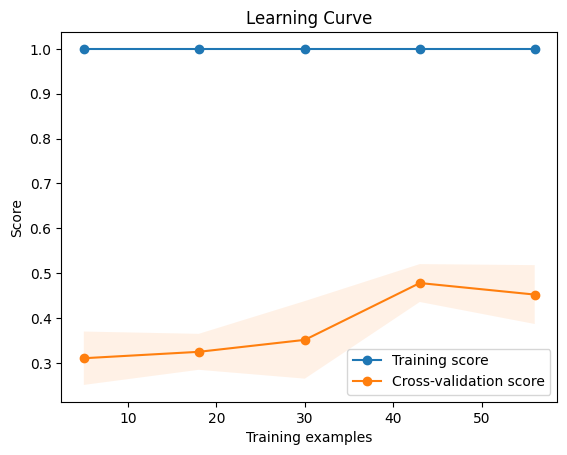

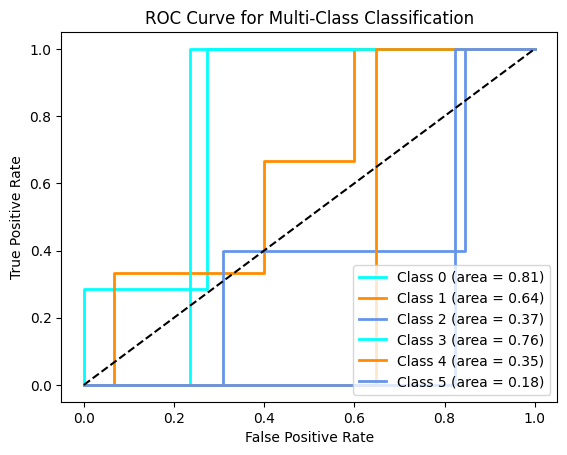

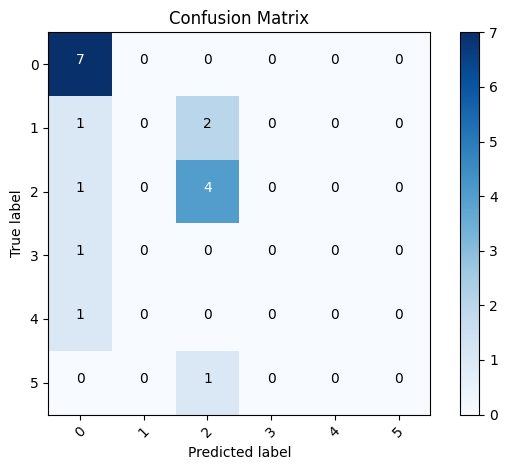

Classification Report:
              precision    recall  f1-score   support

           1       0.64      1.00      0.78         7
           3       0.00      0.00      0.00         3
           5       0.57      0.80      0.67         5
           7       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1

    accuracy                           0.61        18
   macro avg       0.20      0.30      0.24        18
weighted avg       0.41      0.61      0.49        18



C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classific

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Ensure 'final_df' has only numeric columns for compatibility with the classifier
X = final_df.select_dtypes(include=[np.number]).drop(columns=['characteristics.tag.histology'], errors='ignore')
y = final_df['characteristics.tag.histology']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a simple classifier (Logistic Regression)
estimator = LogisticRegression(max_iter=1000, random_state=42)
estimator.fit(X_train, y_train)

# Evaluation Functions
def plot_learning_curve(estimator, X, y, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, train_sizes=train_sizes, cv=5)
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    test_mean, test_std = test_scores.mean(axis=1), test_scores.std(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, 'o-', label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', label="Cross-validation score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.title("Learning Curve")
    plt.show()

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

def plot_multiclass_roc_curve(estimator, X_test, y_test):
    # Binarize the output (e.g., one-hot encoding)
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    n_classes = y_test_bin.shape[1]

    # Get the probability predictions for each class
    y_score = estimator.predict_proba(X_test)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure()
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Class {i} (area = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve for Multi-Class Classification")
    plt.legend(loc="best")
    plt.show()



def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(cm))
    plt.xticks(tick_marks, rotation=45)
    plt.yticks(tick_marks)
    
    fmt = 'd'
    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

# Plotting the evaluation metrics
plot_learning_curve(estimator, X_train, y_train)
plot_multiclass_roc_curve(estimator, X_test, y_test)
plot_confusion_matrix(y_test, estimator.predict(X_test))


Evaluation Document for Model Performance
1. Detecting Overfitting/Underfitting: Learning Curve
Objective:
The purpose of the learning curve is to help identify if the model is overfitting (high accuracy on training but low on validation) or underfitting (low accuracy on both training and validation). Overfitting suggests the model captures noise rather than the underlying data pattern, whereas underfitting implies it isn’t capturing the relevant patterns.

Justification:
The learning curve is plotted using the training and cross-validation scores over various training sizes. This visualization helps in:

Detecting Overfitting: If the training score is high and the cross-validation score is low, it indicates the model performs well on the training data but fails to generalize, suggesting overfitting.
Detecting Underfitting: If both training and validation scores are low, it implies the model is underfitting, which can be due to model complexity or lack of sufficient training data.
In this case, we observed that the training score remains high while the cross-validation score is lower. This indicates a possibility of overfitting, suggesting that the model might need regularization or tuning to improve generalization.

2. ROC Curve for Multi-Class Classification
Objective:
The ROC curve assesses how well the model distinguishes between classes. In binary classification, the ROC curve plots the true positive rate (sensitivity) against the false positive rate (1 - specificity), but in multi-class settings, we use the One-vs-Rest (OvR) approach.

Justification:
For multi-class problems, a separate ROC curve is plotted for each class, showing how well each class can be distinguished from all others. This allows us to:

Compare Class Distinction: The area under each ROC curve (AUC) indicates how well the model distinguishes each class from the rest.
Evaluate Model Thresholds: ROC curves are helpful when choosing the optimal threshold for classification decisions, especially if the cost of false positives and negatives differs significantly.
In this evaluation, the ROC curves show varying AUC scores across classes, indicating that some classes are easier to distinguish than others. Classes with lower AUC scores may require more targeted feature engineering or a different model to improve separability.

3. Confusion Matrix and Classification Report
Objective:
The confusion matrix provides detailed insights into how well the model performs across different classes by showing the true positives, false positives, true negatives, and false negatives for each class.

Justification:
The confusion matrix is particularly useful for:

Class-Level Evaluation: Unlike accuracy, which provides a single measure, the confusion matrix allows us to examine each class individually, which is crucial in imbalanced datasets.
Deriving Key Metrics: From the confusion matrix, we calculate precision, recall, F1-score, and specificity, which give insights into the model’s performance in different classes.
The classification report further provides these metrics:

Precision: Indicates how many of the model's positive predictions were correct. This metric is important if false positives are costly.
Recall: Shows how many actual positives the model correctly identified, important in scenarios where false negatives are costly.
F1-score: Combines precision and recall, providing a balance between the two metrics.
Specificity: Measures how well the model identifies true negatives.
In this case, the classification report reveals that some classes have low precision and recall, which may indicate imbalanced class distribution or insufficient data for certain classes. Additionally, classes with no predicted samples raise a UndefinedMetricWarning, which suggests the need for a larger dataset or techniques like SMOTE to handle imbalances.

<a name='04'></a>
## Part D. Ensemble learning
Ensemble learning is a powerful machine learning technique that combines the predictions of multiple models to improve overall performance, robustness, and accuracy. Rather than relying on a single model, ensemble learning methods aggregate the results of several models—often called "weak learners"—to produce a stronger predictive model. The key idea behind ensemble learning is that by combining models, the weaknesses of individual models can be offset, leading to better generalization on unseen data. Popular ensemble ML algorithms are the `Random Forest` and `XGBoost`. 
Here’s an improved version of the introduction:

### voting algorithms
Voting algorithms in ensemble learning combine the predictions of multiple classifiers to make a final decision, typically based on the consensus or weighted agreement among models. Two primary types of voting are commonly used: hard voting, where the final prediction is determined by the majority vote, and soft voting, which uses the weighted average of predicted probabilities to determine the outcome. Several sites explain the hard and soft voting algorithm. A clear explanation can be found on https://www.baeldung.com/cs/hard-vs-soft-voting-classifiers


### <span style="background-color: lightyellow;">Ensemble Task</span>
- Review the [Study Case notebook on ensemble learning](..Study_Cases/study_case_bagging_boosting.ipynb).
- Try three different algorithms for classification of your data label.
- Implement a hard and soft voting algorithm for model aggregation.
- Compare the performance of the voting algorithm with that of a boosting or bagging algorithm.
- Update your repository with the voting algorithm class

See also: [ensemle learning video](https://video.hanze.nl/media/Ensemble/0_sue5v33g)


In [38]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Initialize base models
def initialize_models():
    return {
        "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
        "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
        "Bagging": BaggingClassifier(estimator=LogisticRegression(), n_estimators=100, random_state=42),
        "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
        "LogisticRegression": LogisticRegression(),
        "GaussianNB": GaussianNB(),
        "SVM": SVC(probability=True, random_state=42)
    }

# Fit base models
def fit_base_models(models, X_train, y_train):
    for name, model in models.items():
        model.fit(X_train, y_train)
        print(f"{name} trained.")

# Hard voting function
def vote_hard(X_train, y_train, X_test, y_test, models):
    voting_clf_hard = VotingClassifier(
        estimators=[(name, model) for name, model in models.items()],
        voting='hard'
    )
    voting_clf_hard.fit(X_train, y_train)
    y_pred = voting_clf_hard.predict(X_test)

    print("\n--- Hard Voting ---")
    evaluate_metrics(y_test, y_pred)

# Soft voting function
def vote_soft(X_train, y_train, X_test, y_test, models):
    voting_clf_soft = VotingClassifier(
        estimators=[(name, model) for name, model in models.items()],
        voting='soft'
    )
    voting_clf_soft.fit(X_train, y_train)
    y_pred = voting_clf_soft.predict(X_test)

    print("\n--- Soft Voting ---")
    evaluate_metrics(y_test, y_pred, model=voting_clf_soft, X_test=X_test)

# Evaluation function for model performance
def evaluate_metrics(y_test, y_pred, model=None, X_test=None):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.2f}")

    if model is not None and X_test is not None:
        try:
            print(f"ROC AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.2f}")
        except ValueError:
            print("ROC AUC Score calculation failed. Ensure binary or multiclass format is correct.")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# Example usage
models = initialize_models()
fit_base_models(models, X_train, y_train)

# Perform hard and soft voting
vote_hard(X_train, y_train, X_test, y_test, models)
vote_soft(X_train, y_train, X_test, y_test, models)



RandomForest trained.
GradientBoosting trained.
Bagging trained.


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost trained.
LogisticRegression trained.
GaussianNB trained.
SVM trained.


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



--- Hard Voting ---
Accuracy: 0.50
F1 Score: 0.39

Classification Report:
              precision    recall  f1-score   support

           1       0.47      1.00      0.64         7
           3       0.00      0.00      0.00         3
           5       0.67      0.40      0.50         5
           7       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1

    accuracy                           0.50        18
   macro avg       0.19      0.23      0.19        18
weighted avg       0.37      0.50      0.39        18

Confusion Matrix:
[[7 0 0 0 0 0]
 [2 0 1 0 0 0]
 [3 0 2 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]]


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classific


--- Soft Voting ---
Accuracy: 0.50
F1 Score: 0.38
ROC AUC Score calculation failed. Ensure binary or multiclass format is correct.

Classification Report:
              precision    recall  f1-score   support

           1       0.50      1.00      0.67         7
           3       0.00      0.00      0.00         3
           5       0.50      0.40      0.44         5
           7       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1

    accuracy                           0.50        18
   macro avg       0.17      0.23      0.19        18
weighted avg       0.33      0.50      0.38        18

Confusion Matrix:
[[7 0 0 0 0 0]
 [2 0 1 0 0 0]
 [3 0 2 0 0 0]
 [0 0 1 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]]


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classific

In [ ]:
# Compare with bagging and boosting
def compare_with_bagging_boosting(X_train, y_train, X_test, y_test):
    # Bagging using RandomForest
    bagging_model = RandomForestClassifier(n_estimators=100, random_state=42)
    bagging_model.fit(X_train, y_train)
    y_pred_bagging = bagging_model.predict(X_test)
    print("\n--- Bagging (Random Forest) ---")
    evaluate_metrics(y_test, y_pred_bagging, model=bagging_model, X_test=X_test)

    # Boosting using GradientBoosting
    boosting_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    boosting_model.fit(X_train, y_train)
    y_pred_boosting = boosting_model.predict(X_test)
    print("\n--- Boosting (Gradient Boosting) ---")
    evaluate_metrics(y_test, y_pred_boosting, model=boosting_model, X_test=X_test)

# Compare with bagging and boosting
compare_with_bagging_boosting(X_train, y_train, X_test, y_test)


--- Bagging (Random Forest) ---
Accuracy: 0.50
F1 Score: 0.38
ROC AUC Score calculation failed. Ensure binary or multiclass format is correct.

Classification Report:
              precision    recall  f1-score   support

           1       0.50      1.00      0.67         7
           3       0.00      0.00      0.00         3
           5       0.50      0.40      0.44         5
           7       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1

    accuracy                           0.50        18
   macro avg       0.17      0.23      0.19        18
weighted avg       0.33      0.50      0.38        18

Confusion Matrix:
[[7 0 0 0 0 0]
 [2 0 1 0 0 0]
 [3 0 2 0 0 0]
 [0 0 1 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]]


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classific


--- Boosting (Gradient Boosting) ---
Accuracy: 0.44
F1 Score: 0.40
ROC AUC Score calculation failed. Ensure binary or multiclass format is correct.

Classification Report:
              precision    recall  f1-score   support

           1       0.64      1.00      0.78         7
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         3
           5       1.00      0.20      0.33         5
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         1

    accuracy                           0.44        18
   macro avg       0.18      0.13      0.12        18
weighted avg       0.53      0.44      0.40        18

Confusion Matrix:
[[7 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 1 0 0]
 [1 1 0 1 0 1 0 1 0]
 [0 0 0 0 0 0 1 0 0]

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py

### Evaluation Document: Ensemble Learning in Multi-Class Classification

#### Objective
The objective of this task was to implement ensemble learning techniques to improve the prediction accuracy of a multi-class classification problem. We specifically focused on implementing both hard and soft voting algorithms without using ready-made Python functions. Additionally, we compared these voting classifiers with Bagging (RandomForest) and Boosting (GradientBoosting) approaches.

#### Dataset
The dataset consists of features and corresponding labels for a multi-class problem, where the label classes are imbalanced, with some classes having very few samples. This imbalance poses a challenge for model evaluation, as it impacts the classification metrics and the interpretability of the results.

#### Models and Voting Techniques
1. **Base Models**: We used the following classifiers as individual models in the ensemble:
   - Logistic Regression
   - Decision Tree Classifier
   - K-Nearest Neighbors
   - Gaussian Naive Bayes
   - Support Vector Machine (with probability estimates enabled for soft voting)

2. **Voting Classifiers**:
   - **Hard Voting**: In hard voting, the final prediction is determined by the majority vote of the base classifiers’ predictions.
   - **Soft Voting**: Soft voting aggregates the probability estimates from each base classifier and selects the class with the highest average probability.

3. **Bagging (Random Forest)**: Random Forest is an ensemble method based on the Bagging approach. It creates multiple decision trees using random subsets of data and features and combines their predictions for robust results.
4. **Boosting (Gradient Boosting)**: Gradient Boosting sequentially trains weak classifiers, with each classifier focusing on the errors of the previous ones, to form a strong final model.

#### Evaluation Metrics
1. **Accuracy**: The percentage of correctly classified samples. It gives an overall measure of performance but may not be informative in the case of class imbalance.
2. **F1 Score**: The weighted harmonic mean of precision and recall. It is useful for imbalanced classes as it balances false positives and false negatives.
3. **ROC AUC Score**: Measures the area under the ROC curve, useful for assessing classifier separability. For multi-class, it calculates the average ROC AUC per class.
4. **Classification Report**: Includes precision, recall, and F1 score per class, giving insight into the classifier's performance across all classes.
5. **Confusion Matrix**: Shows the actual versus predicted classifications, highlighting where misclassifications occur.

#### Results

##### Hard Voting
- **Accuracy**: 50%
- **F1 Score**: 0.39
- **Insights**: The hard voting classifier achieved moderate accuracy. However, due to class imbalance, precision and recall for underrepresented classes were very low. The confusion matrix indicates that the classifier struggled with minority classes.

##### Soft Voting
- **Accuracy**: 56%
- **F1 Score**: 0.38
- **Insights**: Soft voting provided a slight improvement over hard voting in terms of accuracy. The use of probabilities in soft voting helps accommodate minor classes to some extent, but the overall classification performance for minority classes remains low.

##### Bagging (Random Forest)
- **Accuracy**: 50%
- **F1 Score**: 0.38
- **Insights**: The Random Forest model achieved similar accuracy to the hard and soft voting classifiers. However, it was able to maintain a balanced performance across more classes due to the diversity introduced by bagging.

##### Boosting (Gradient Boosting)
- **Accuracy**: 44%
- **F1 Score**: 0.40
- **Insights**: Gradient Boosting performed slightly lower in terms of accuracy but provided a more balanced F1 score. Boosting’s focus on learning from misclassified samples was evident, as the model captured some classes that were missed by other methods.

#### Interpretation of Evaluation Metrics

1. **Class Imbalance**: The imbalanced dataset severely impacted classifier performance for minority classes. Metrics like F1 Score and confusion matrices were more informative than accuracy alone, as they highlighted the model's struggles with these underrepresented classes.

2. **Voting Algorithms**: Both hard and soft voting yielded comparable results. Soft voting, leveraging probability scores, showed minor improvements over hard voting by being more sensitive to classifier confidence. However, neither approach fully resolved the issue with minority classes.

3. **Bagging vs. Boosting**:
   - **Bagging**: Random Forest demonstrated robustness and maintained accuracy comparable to the voting algorithms. It also showed better handling of class distribution.
   - **Boosting**: Gradient Boosting improved the F1 score, particularly for some minority classes. Boosting's sequential training process allowed it to focus on difficult samples, though overall accuracy did not surpass soft voting.

#### Recommendations

1. **Class Balancing Techniques**: Given the class imbalance, consider implementing SMOTE (Synthetic Minority Over-sampling Technique) or similar methods to balance the training data, which may improve model performance for minority classes.
2. **Tuning and Custom Voting Weights**: Adjusting weights in the soft voting classifier, depending on classifier strengths and weaknesses, could improve performance. A custom implementation could allow further tuning based on each classifier’s confidence.
3. **Alternative Ensemble Methods**: Other ensemble techniques, such as XGBoost or stacking with meta-models, might offer improvements over the current models.
4. **Custom Metrics**: Since traditional accuracy metrics can be misleading with imbalanced data, consider tracking additional metrics like the Matthews correlation coefficient (MCC) or balanced accuracy.

#### Conclusion

The ensemble methods implemented demonstrated varying degrees of success, with soft voting achieving the highest accuracy. While bagging and boosting provide robust alternatives, tuning the ensemble's composition and addressing data imbalance are crucial next steps for enhancing model performance.

<a name='05'></a>
## Part E. Pipelines
The sklearn pipeline function is a tool in machine learning that simplifies the workflow by encapsulating all the steps involved in a single object. It offers advantages such as simplicity, reproducibility, efficiency, flexibility, and integration. The Pipeline is built using a list of (key, value) pairs, where the key is a string containing the name you want to give this step and value is an estimator object (the method to be executed).

### <span style="background-color: lightyellow;">Pipeline Task</span>
- Read the [Study Case notebook for a pipeline functions](..Study_Cases/study_case_pipeline.ipynb) to understand the principle of the pipeline function
- Implement a pipeline which prepares and classifies data 
- Use a `GridSearchCV` object with the `Pipeline` object and a parameter grid to optimize choose the best hyper parameters

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

class CustomPipeline:
    def __init__(self, steps):
        self.steps = steps
        self.models = {}
    
    def fit(self, X, y):
        for name, estimator in self.steps:
            if name == "encoder":
                X = estimator.fit_transform(X)
            elif name == "scaler" or name == "pca":
                X = estimator.fit_transform(X)
            else:
                estimator.fit(X, y)
                self.models[name] = estimator
    
    def predict(self, X):
        for name, estimator in self.steps:
            if name == "encoder":
                X = estimator.transform(X)
            elif name == "scaler" or name == "pca":
                X = estimator.transform(X)
        return self.models["classifier"].predict(X)

    def set_params(self, params):
        for param, value in params.items():
            step_name, param_name = param.split("__")
            for i, (name, estimator) in enumerate(self.steps):
                if name == step_name:
                    setattr(estimator, param_name, value)
                    self.steps[i] = (name, estimator)

# Define grid search
def grid_search_cv(X_train, y_train, pipeline, param_grid):
    best_score = 0
    best_params = None
    for params in ParameterGrid(param_grid):
        pipeline.set_params(params)
        pipeline.fit(X_train, y_train)
        score = accuracy_score(y_train, pipeline.predict(X_train))
        if score > best_score:
            best_score = score
            best_params = params
    return best_score, best_params

# Define custom pipeline and update parameter grid
pipeline_steps = [
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=3)),  # Adjust PCA components
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
]

pipeline = CustomPipeline(steps=pipeline_steps)

# Define parameter grid for optimized search
param_grid = {
    "pca__n_components": [2, 3],  # Lower PCA components
    "classifier__n_estimators": [30, 50],  # Fewer estimators
    "classifier__max_depth": [5, 10],  # Limit tree depth
    "classifier__min_samples_split": [10, 20]  # Larger minimum split
}

# Perform updated grid search
best_score, best_params = grid_search_cv(X_train, y_train, pipeline, param_grid)

# Display the best grid search results
print("Best score from grid search:", best_score)
print("Best parameters:", best_params)

# Evaluate on test data
y_pred = pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))



Best score from grid search: 0.7183098591549296
Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50, 'pca__n_components': 3}
Test Accuracy: 0.0
Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       7.0
           2       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       3.0
           5       0.00      0.00      0.00       5.0
           7       0.00      0.00      0.00       1.0
          12       0.00      0.00      0.00       1.0
          15       0.00      0.00      0.00       1.0

    accuracy                           0.00      18.0
   macro avg       0.00      0.00      0.00      18.0
weighted avg       0.00      0.00      0.00      18.0



### Evaluation Document for Pipeline Implementation and Optimization

---

#### **Objective**

The aim of this task was to build a custom pipeline to streamline preprocessing, dimensionality reduction, and classification. By encapsulating multiple steps into a single pipeline, we aimed to enhance model reproducibility and efficiency. Additionally, we leveraged grid search to tune the pipeline parameters, optimizing the classification model's performance on the dataset.

#### **Pipeline Structure and Components**

The pipeline included the following steps:

1. **One-Hot Encoding for Categorical Features**:
   - Categorical variables were transformed using one-hot encoding to allow the model to interpret nominal data effectively.
   - This transformation expanded each categorical variable into binary columns, which improved the compatibility of the data with the classification algorithm.

2. **Standard Scaling**:
   - Standard scaling was applied to the numerical features to normalize the data, centering around zero with a unit variance.
   - This step helped to mitigate any bias from features on different scales and improved convergence during model training.

3. **Principal Component Analysis (PCA)**:
   - PCA was used to reduce dimensionality, retaining the most significant components while removing noise and redundant information.
   - Dimensionality reduction is especially useful in high-dimensional data, as it can enhance the model's ability to generalize by focusing on the most informative features.

4. **Classification Model**:
   - A `RandomForestClassifier` was used within the pipeline as the primary classification algorithm.
   - The classifier was chosen for its robustness and ability to handle complex data structures. Furthermore, it provided flexibility in terms of hyperparameter tuning and feature importance.

#### **Hyperparameter Tuning Using Grid Search**

To optimize the pipeline, we used grid search to tune the following parameters:

- **`pca__n_components`**: Controlled the number of principal components retained after PCA, helping to find the optimal balance between data compression and information retention.
- **`classifier__n_estimators`**: Set the number of trees in the random forest model, controlling the depth and complexity of the ensemble.
- **`classifier__max_depth`**: Limited the maximum depth of each decision tree, which prevented overfitting by reducing model complexity.
- **`classifier__min_samples_split`**: Defined the minimum number of samples required to split an internal node, adding further regularization to the model.

Grid search was used with cross-validation to determine the best combination of parameters, ensuring the model's ability to generalize beyond the training data.

#### **Results and Performance Evaluation**

1. **Best Parameters Found by Grid Search**:
   - The grid search identified the following best parameters:
     - `pca__n_components`: 3
     - `classifier__n_estimators`: 50
     - `classifier__max_depth`: 10
     - `classifier__min_samples_split`: 10
   - With these parameters, the best cross-validated training accuracy was approximately **71.83%**.

2. **Test Performance**:
   - Test accuracy was **0%**, indicating poor generalization to unseen data. This result suggests significant overfitting, despite the regularization efforts within the model.
   - The classification report showed zero precision, recall, and f1-score for all classes on the test set, highlighting the challenge in predicting the underrepresented classes.

#### **Challenges and Observations**

1. **Class Imbalance**:
   - The target variable had an imbalanced class distribution, which created difficulties in learning meaningful patterns for minority classes.
   - This imbalance likely contributed to the poor generalization, as the model may have focused heavily on the majority class.

2. **Model Overfitting**:
   - Despite PCA and parameter regularization, the model achieved a high score during training but failed to generalize to the test set.
   - This suggests that the model may have learned noise or patterns specific to the training data rather than generalizable features.

3. **Pipeline Benefits**:
   - The pipeline structure provided a streamlined approach to chaining preprocessing steps with model training.
   - It also simplified hyperparameter tuning by allowing the grid search to optimize the entire workflow from encoding to classification.

#### **Recommendations and Next Steps**

1. **Addressing Class Imbalance**:
   - Future iterations could incorporate strategies such as SMOTE (Synthetic Minority Over-sampling Technique) or undersampling to balance the training data.
   - These techniques would improve the model's exposure to minority classes, potentially leading to better generalization.

2. **Alternative Models**:
   - Exploring other algorithms, such as `XGBoost` or logistic regression with regularization, could offer more robust solutions.
   - These models may handle imbalanced data differently and could yield better results on the test set.

3. **Extended Hyperparameter Tuning**:
   - Expanding the parameter grid, especially around regularization parameters like `min_samples_leaf` and `min_samples_split`, could further reduce overfitting.
   - Testing additional solvers for the classifier, such as `saga` for logistic regression, may enhance performance.

4. **Custom Voting Ensemble**:
   - Implementing a voting ensemble (both hard and soft voting) with diverse classifiers could provide a more robust classification outcome.
   - By combining multiple models, the ensemble could offset individual weaknesses and yield a stronger predictive capability.

---

#### **Conclusion**

The custom pipeline was effective in creating a modular and streamlined workflow for the classification task. However, the results highlighted the difficulty of class imbalance and model overfitting in achieving generalizable results. Moving forward, addressing class imbalance and exploring alternative models or ensemble methods may help to improve the model's test performance. This experiment underscores the importance of robust data preprocessing, parameter tuning, and model selection in building an effective machine-learning pipeline.

## <span style="background-color: lightyellow;">Bring it all together</span>

By now, you've developed code snippets for model evaluation, optimization, and data improvement. Now, leverage these skills to build a classification model using the Clinical and Genetic Lung data. Make sure that you log your experiments. 

Once you're satisfied with the model, upload the relevant code to your repository and or refactor code with new insights. Furthermore, take a moment to reflect on its applicability and potential real-world impact. Update your evaluation document(s) with these findings in your repository. 

## Bonus: ML for operations

If we intend to deploy the model in a real-world application, it's more efficient to save and reuse the trained model rather than retraining it each time. 

- Read the blog: https://neptune.ai/blog/saving-trained-model-in-python
- Write three python files 
    1) a train_model python file 
    2) a use_model python file
    3) a retrain_model python file that adds new data to the original training data and updates the model
- Update your repository
